Complete the exercises below For **Assignment #5**.

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library. 

In [1]:
library("tidymodels")


── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.13     ✔ recipes      1.3.3 
✔ dials        1.4.4      ✔ rsample      1.3.2 
✔ dplyr        1.2.1      ✔ tailor       0.1.0 
✔ ggplot2      4.0.3      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.0.1 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.6.0      ✔ workflowsets 1.1.1 
✔ purrr        1.2.2      ✔ yardstick    1.4.0 

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()



The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [2]:
diabetes = readr::read_csv('diabetes.csv') |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

Rows: 768 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Glimpse the `diabetes_train` table.

In [8]:
glimpse(diabetes_train)


Rows: 576
Columns: 9
$ Pregnancies              <dbl> 1, 5, 10, 4, 10, 8, 13, 5, 5, 6, 10, 4, 11, 3…
$ Glucose                  <dbl> 89, 116, 115, 110, 139, 99, 145, 117, 109, 92…
$ BloodPressure            <dbl> 66, 74, 0, 92, 80, 84, 82, 92, 75, 92, 78, 60…
$ SkinThickness            <dbl> 23, 0, 0, 0, 0, 0, 19, 0, 26, 0, 31, 33, 0, 2…
$ Insulin                  <dbl> 94, 0, 0, 0, 0, 0, 110, 0, 0, 0, 0, 192, 0, 7…
$ BMI                      <dbl> 28.1, 25.6, 35.3, 37.6, 27.1, 35.4, 22.2, 34.…
$ DiabetesPedigreeFunction <dbl> 0.167, 0.201, 0.134, 0.191, 1.441, 0.388, 0.2…
$ Age                      <dbl> 21, 30, 29, 30, 57, 50, 57, 38, 60, 28, 45, 3…
$ Outcome                  <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


❓ Which variable is suitable as the "outcome" in a logistic regression model?

**Answer:**

The `Outcome` column can be considered to be the most suitable output of the regression model, given outcome is the prediction of being diabetic.

❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

| Column name | Description |
| :---------- | :---------- |
| Glucose     |      Plasma Glucose Concentration a 2-hour in an Oral Glucose Tolerance Test (mg/dl).       |
| BMI         |      Body Mass Index (weight in kg/(height in m)^2)        |

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

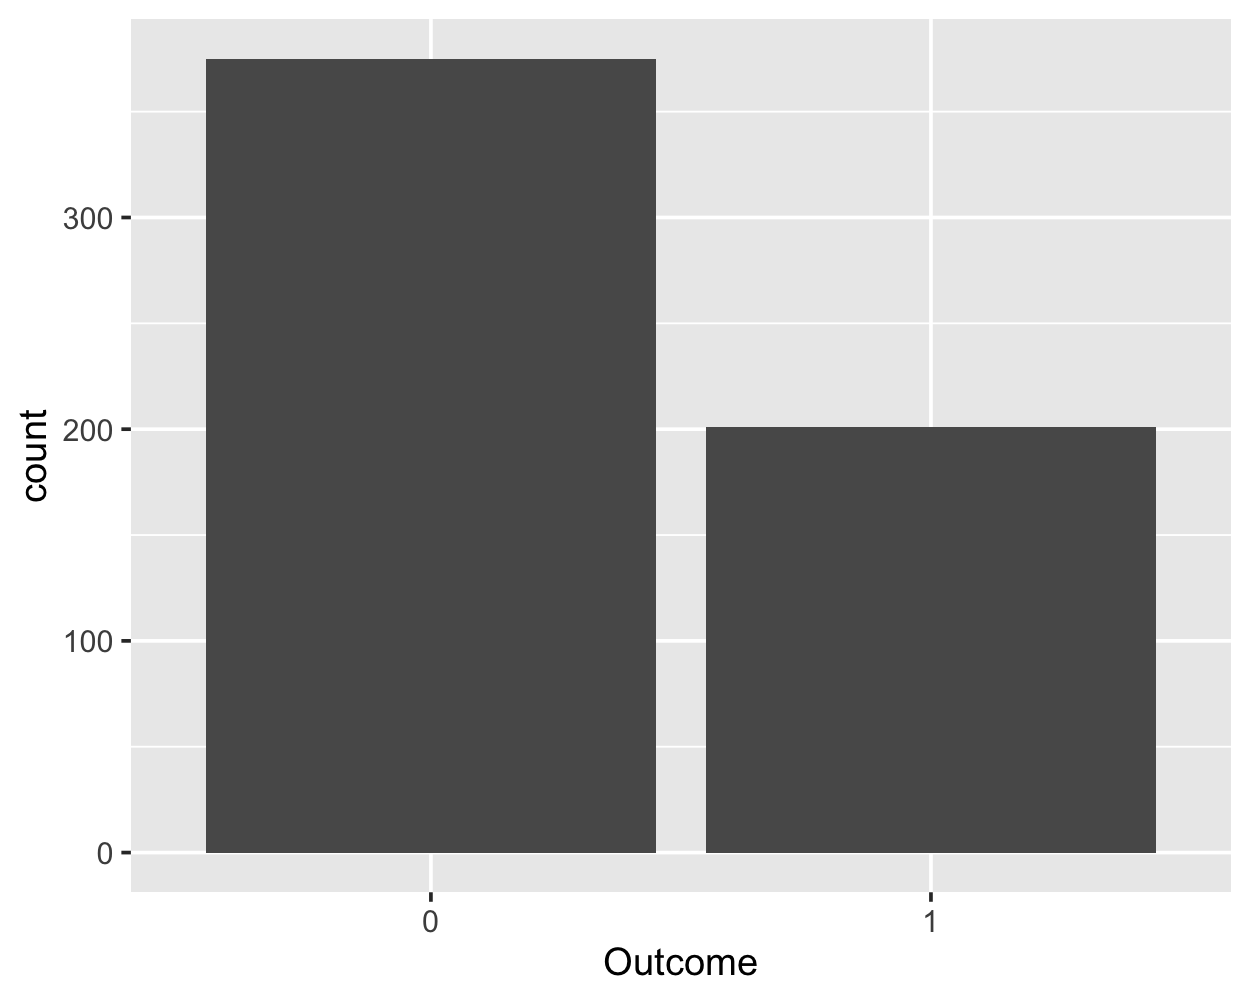

In [9]:
diabetes_train |> ggplot(aes(x = Outcome)) + 
    geom_bar()

❓ Is the data balanced? I.e. do we have equal counts of each outcome?

**Answer:**

The data is not balanced and the counts of each outcome are considerably different. Namely, roughly two-thirds of the training data set has the outcome of `0` while the other third has an outcome of `1`.



Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`. 

In [15]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
0,Glucose,89.0
0,BMI,28.1
0,Glucose,116.0
0,BMI,25.6
0,Glucose,115.0
0,BMI,35.3


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`. 

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

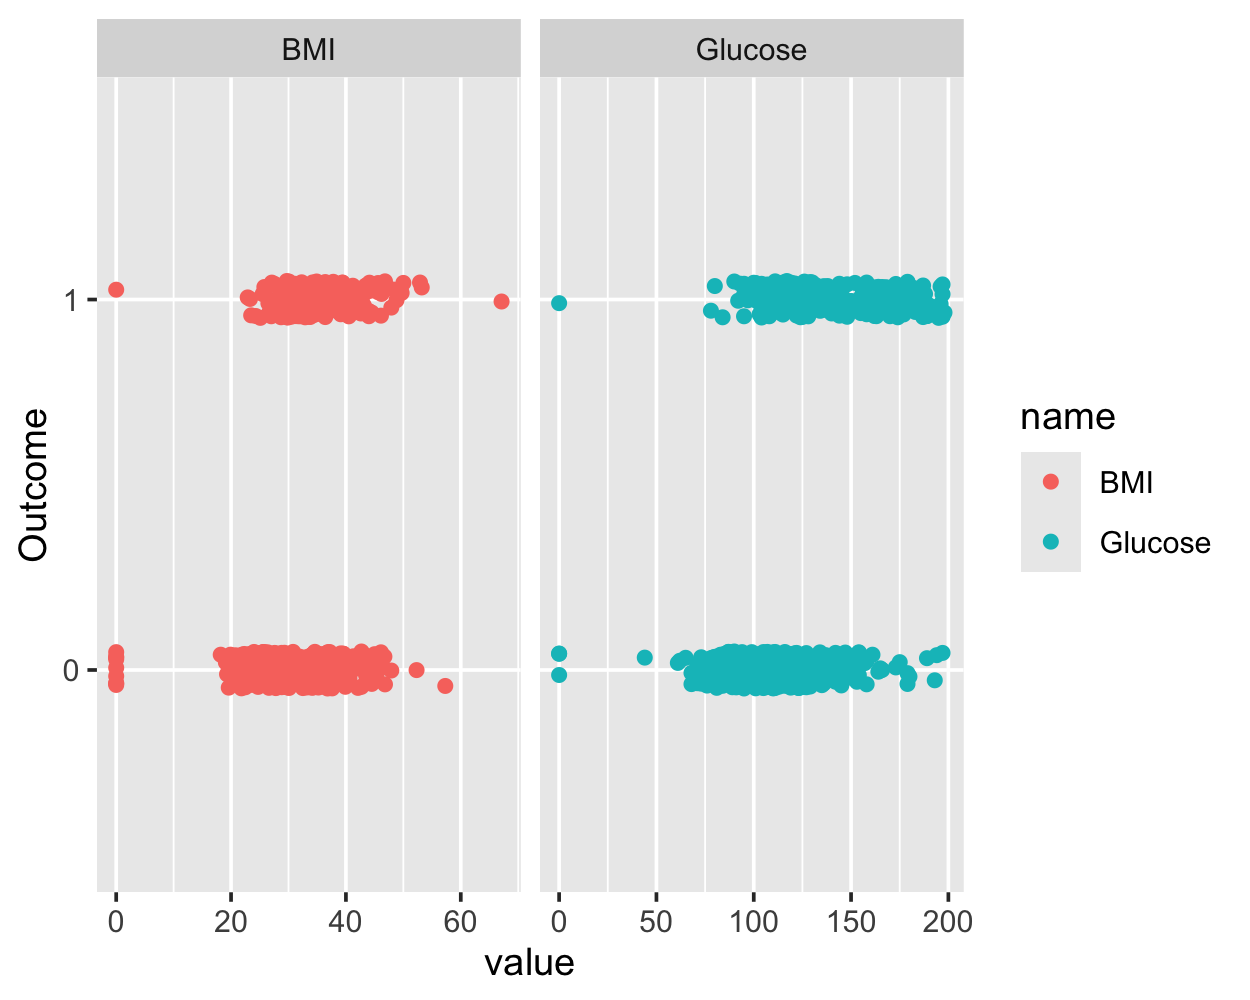

In [22]:
plot_df |> ggplot(aes(x= value, y= Outcome, color= name)) +
        geom_jitter(height= .05, width= 0) +
        facet_wrap(~name, ncol = 2, scales = 'free_x')



❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

**Answer:**

The domain of the `BMI ~ Outcome` plot is not scaled to the actual range of that domain and is instead using the range of the larger `Glucose ~ Outcome` domain.

Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors. 
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

In [32]:
mod = logistic_reg() |>
    set_engine("glm")

mod_fit = mod |> fit(Outcome ~ BMI + Glucose, data= diabetes_train)


Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model. 

In [33]:
diabetes_test_wPred = augment(mod_fit, diabetes_test)
head(diabetes_test_wPred)



.pred_class,.pred_0,.pred_1,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
0,0.9315935,0.06840652,1,85,66,29,0,26.6,0.351,31,0
0,0.8263222,0.17367776,7,107,74,0,0,29.6,0.254,31,1
0,0.6241980,0.37580203,1,103,30,38,83,43.3,0.183,33,0
0,0.5077347,0.49226526,3,126,88,41,235,39.3,0.704,27,0
0,0.6862564,0.31374359,10,125,70,26,115,31.1,0.205,41,1
0,0.9225467,0.07745325,1,97,66,15,140,23.2,0.487,22,0


Run the code below to generate a confusion matrix for your model predictions. 

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [35]:
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)

diabetes_test_wPred |> conf_mat(Outcome, .pred_class)

          Truth
Prediction   0   1
         0 104  37
         1  21  30

❓ Based on the confusion matrix above, 
- How many individuals had diabetes in your test data?
- Of those that actually had diabetes, how many were predicted to have diabetes by your model?
- How many individuals predicted to have diabetes did not have diabetes?

**Answer:**

According to the confusion matrix, 67 individuals had diabetes.
Given a person actually had diabetes, the correctly predicted the outcome for 30 individuals.
The model incorrectly predicted an individual had diabetes 21 times.


